Training started...

EVALUATION: 1 | TIMESTEPS: 1024
Step (q)   | Decision (n_d)  | Dose D_d(q) [mg]   | Conc C_d(q) [mg/L]   | Tumor ln(N) P_d
--------------------------------------------------------------------------------
q = 1      | 0               | 0                  | 0.0000               | 23.0284        
q = 2      | 0               | 0                  | 0.0000               | 23.0309        
q = 3      | 0               | 0                  | 0.0000               | 23.0334        
q = 4      | 0               | 0                  | 0.0000               | 23.0359        
q = 5      | 0               | 0                  | 0.0000               | 23.0384        
q = 6      | 0               | 0                  | 0.0000               | 23.0409        
q = 7      | 0               | 0                  | 0.0000               | 23.0434        
q = 8      | 0               | 0                  | 0.0000               | 23.0458        
q = 9      | 0               | 0               

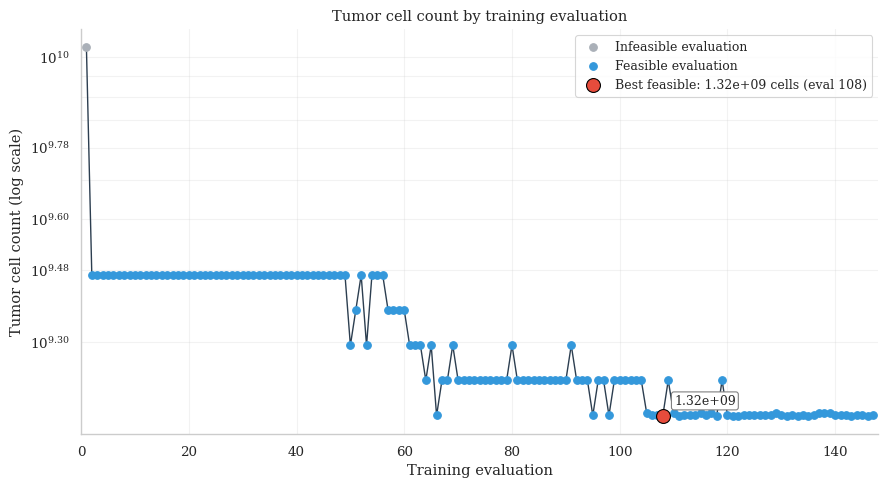

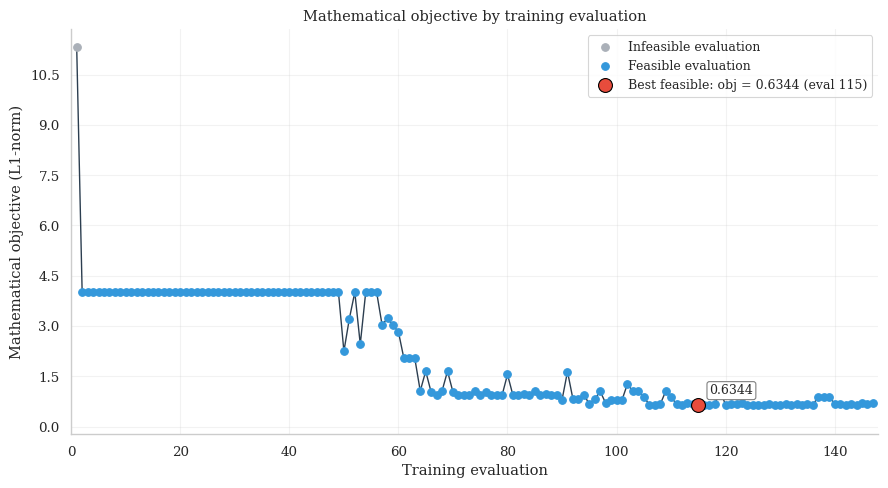

In [1]:
import gymnasium as gym
from gymnasium import spaces

import numpy as np
import random

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

import matplotlib.pyplot as plt
import seaborn as sns

class HydroxyureaEnv(gym.Env):
    """
    Single-drug Hydroxyurea scheduling environment.

    PK: one-compartment oral model. PD: Gompertzian growth (log-transformed, Euler).
    Objective: L1-norm trajectory tracking + dose penalty (MILP surrogate via RL).

    Constraints:
        C1  Discrete dosing:         D_d(q) = 500 * n_d(q)
        C2  Logical coupling:        500*b_d <= D_d <= D_max*b_d
        C3  Min consecutive dosing:  15-step block once started (penalty)
        C4  Max consecutive dosing:  sliding window L_max (hard)
        C5  Per-step dose bound:     D_d(q) <= D_max (hard)
        C6  Total cycle minimum:     sum(D_d) >= D_total_min (end-of-episode penalty)
        C7  Total cycle maximum:     sum(D_d) <= D_total_max (hard)
        C8  Cumulative AUC toxicity: trapezoidal rule <= C_cum (penalty)
        C9  Efficacy:                P_d(q) <= ln(N_0) for q >= 3 (penalty)
    """

    def __init__(self, config=None):
        super().__init__()
        cfg = config or {}

        # Time discretization
        self.h = 12                        # hours per step
        self.T = cfg.get("T", 22)          # total steps (11 days x 2/day)

        # Dosing (C1, C2, C5)
        self.dose_unit = 500               # mg per capsule
        self.n_max     = cfg.get("n_max", 2)
        self.D_max     = self.n_max * self.dose_unit   # 1000 mg max per step

        # Cycle dose bounds (C6, C7)
        self.D_total_min = cfg.get("D_total_min", 10000)  # mg
        self.D_total_max = cfg.get("D_total_max", 20000)  # mg

        # Consecutive dosing (C3, C4)
        # Patient dosed continuously all 22 steps; L_max = T means no forced break
        self.L_min = cfg.get("L_min", 15)  # min consecutive steps once started
        self.L_max = cfg.get("L_max", 22)  # max consecutive steps

        # Toxicity limits (C8, acute)
        self.C_cum = cfg.get("C_cum", 1500.0)  # mg/L*h  AUC limit
        self.C_max = cfg.get("C_max", 50.0)    # mg/L    peak concentration limit

        # Penalty weights
        self.Gamma_u = cfg.get("Gamma_u",  1e-5)  # dose penalty (objective term)
        self.pen_c3  = cfg.get("pen_c3",   5.0)   # C3: interruption penalty per step
        self.pen_c8  = cfg.get("pen_c8",   10.0)  # C8: AUC violation penalty
        self.pen_c9  = cfg.get("pen_c9",   5.0)   # C9: per log-unit above ln(N_0)
        self.pen_c6  = cfg.get("pen_c6",   20.0)  # C6: end-of-episode underdose penalty

        # Evaluation / target trajectory
        self.eval_interval = cfg.get("eval_interval", 2)
        self.W             = self.T // self.eval_interval

        # PK parameters (Hydroxyurea, one-compartment oral)
        self.gamma = cfg.get("gamma", 0.198)  # h^-1  elimination rate; t_half=3.5h -> ln(2)/3.5; Gwilt & Tracewell (1998) Table I
        self.V_d   = cfg.get("V_d",   35.0)   # L     volume of distribution (~0.5 L/kg x 70 kg)
        self.F     = cfg.get("F",     0.79)   # oral bioavailability; Gwilt & Tracewell (1998) p.349

        # Precomputed coefficients for exact one-compartment solution
        self.pk_decay      = np.exp(-self.gamma * self.h)
        self.pk_dose_coeff = (self.F / (self.V_d * self.gamma * self.h)) * (1.0 - self.pk_decay)

        # PD parameters (Gompertzian, log-transformed)
        self.tau_g   = cfg.get("tau_g", 3600.0)  # h  growth time constant (5 months x 30 x 24); H&P Table 1
        self.theta_g = cfg.get("theta_g", 1e12)    # cells  carrying capacity; H&P Table 1
        self.N_0     = cfg.get("N_0",     1e10)    # cells  initial tumor size; H&P Table 1
        self.k_eff   = cfg.get("k_eff",   4e-3)  # h^-1/(mg/L)  drug efficacy constant
        # C_th = 8.0 mg/L (sensitivity analysis): peak C_d ~ 9 mg/L at max dose,
        # so C_th=10 (H&P original) would give C_eff=0 always, drug has no effect.
        self.C_th    = cfg.get("C_th",    8.0)     # mg/L  effect threshold

        # Gompertz growth coefficient (constant across all steps)
        self.lam = (1.0 / self.tau_g) * np.log(
            np.log(self.theta_g / self.N_0) /
            np.log(self.theta_g / (2.0 * self.N_0))
        )
        self.ln_theta_g = np.log(self.theta_g)
        self.ln_N0      = np.log(self.N_0)

        # Clinician-specified target: linear decrease in log-tumor over W eval points
        ln_end   = self.ln_N0 - cfg.get("target_reduction", 2.0)
        self.T_d = np.linspace(self.ln_N0, ln_end, self.W)

        # Action and observation spaces
        self.action_space = spaces.Discrete(self.n_max + 1)  # 0..n_max capsules
    
        # State: [step_norm, P_d, C_d, cumul_dose_norm, consec_norm, auc_norm]
        self.observation_space = spaces.Box(
            low  = np.array([0.0, -30.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high = np.array([1.0,  30.0, self.C_max, 1.0, 1.0, 1.0], dtype=np.float32),
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t                 = 0
        self.P_d               = self.ln_N0   # log-tumor starts at ln(N_0)
        self.C_d               = 0.0          # plasma concentration starts at 0
        self.cumulative_dose   = 0.0
        self.consecutive_doses = 0
        self.treatment_started = False
        self.steps_since_start = 0
        self.auc               = 0.0
        self.eval_index        = 0

        self.dose_history  = []
        self.tumor_history = [self.P_d]
        self.conc_history  = [self.C_d]
        self.z_w_history   = []  # L1 deviations at each evaluation point

        return self._obs(), {}

    def step(self, action):
        n_d    = int(action)  # C1: capsules n_d(q) in {0,...,n_max}
        reward = 0.0

        # C4: hard cap on consecutive dosing
        if self.consecutive_doses >= self.L_max and n_d > 0:
            n_d = 0
        # C7: hard cap on total cycle dose
        remaining = self.D_total_max - self.cumulative_dose
        n_d = min(n_d, int(remaining // self.dose_unit))

        # C1/C2: discrete dose and binary indicator
        D_d = n_d * self.dose_unit
        b_d = 1 if D_d > 0 else 0

        # Track when treatment begins (for C3)
        if b_d and not self.treatment_started:
            self.treatment_started = True
            self.steps_since_start = 0
        if self.treatment_started:
            self.steps_since_start += 1

        # C3: penalize interruption within the first L_min steps of treatment
        if self.treatment_started and self.steps_since_start <= self.L_min and b_d == 0:
            reward -= self.pen_c3

        self.consecutive_doses = self.consecutive_doses + 1 if b_d else 0
        self.cumulative_dose  += D_d
        self.dose_history.append(D_d)

        # PK: exact one-compartment solution C(q+1) = decay*C(q) + coeff*D(q)
        self.C_d = self.pk_decay * self.C_d + self.pk_dose_coeff * D_d
        self.conc_history.append(self.C_d)

        # C8: trapezoidal AUC accumulation; penalize if limit exceeded
        w_auc = (self.h / 2.0) if (self.t == 0 or self.t == self.T - 1) else self.h
        self.auc += w_auc * self.C_d
        if self.auc > self.C_cum:
            reward -= self.pen_c8

        E_max = 1.0
        EC50  = self.C_th
        hill_n = 2.0
        
        C_eff = E_max * (self.C_d ** hill_n) / (EC50 ** hill_n + self.C_d ** hill_n)

        self.P_d = (
            (1.0 - self.h * self.lam) * self.P_d
            + self.h * self.lam * self.ln_theta_g
            - self.h * self.k_eff * C_eff * self.C_d
        )

        self.tumor_history.append(self.P_d)

        # C9: efficacy, tumor must not exceed initial size (skip first 2 steps for lag)
        if self.t >= 2 and self.P_d > self.ln_N0:
            reward -= self.pen_c9 * (self.P_d - self.ln_N0)

        # Objective term: dose penalty Gamma_u * D_d(q)
        reward -= self.Gamma_u * D_d

        self.t += 1
        # Objective term: L1 trajectory deviation z(w) at each evaluation point
        if self.t % self.eval_interval == 0 and self.eval_index < self.W:
            z_w = abs(self.P_d - self.T_d[self.eval_index])
            reward -= z_w
            self.z_w_history.append(z_w)
            self.eval_index += 1

        done = self.t >= self.T


        if done and self.cumulative_dose < self.D_total_min:
            deficit = self.D_total_min - self.cumulative_dose
            reward -= self.pen_c6 * (deficit / self.D_total_min)
        

        return self._obs(), reward, done, False, {}

    def _obs(self):
        return np.array([
            self.t / self.T,
            self.P_d,
            self.C_d,
            self.cumulative_dose / self.D_total_max,
            self.consecutive_doses / (self.L_max + 1),
            min(self.auc / self.C_cum, 1.0),
        ], dtype=np.float32)


class EpisodeCallback(BaseCallback):
    """
    Deterministic evaluation episode run every eval_freq timesteps.
    Tracks tumor cell count and feasibility per evaluation. Use silent=True for batch runs.
    """
    def __init__(self, eval_env_config, eval_freq, silent=False, verbose=0):
        super().__init__(verbose)
        self.eval_env    = HydroxyureaEnv(eval_env_config)
        self.eval_freq   = eval_freq
        self.silent      = silent
        self.eval_count = 0
        self.history_evals   = []
        self.history_cells    = []
        self.history_feasible = []  # True if C8 (AUC) and C6 (min dose) are both satisfied
        self.history_objs     = []  # mathematical objective per evaluation

    def _on_step(self) -> bool:
        if self.num_timesteps % self.eval_freq == 0:
            self.eval_count += 1
            obs, _ = self.eval_env.reset()
            total_reward = 0.0

            if not self.silent:
                print(f"\n{'=' * 80}")
                print(f"EVALUATION: {self.eval_count} | TIMESTEPS: {self.num_timesteps}")
                print(f"{'Step (q)':<10} | {'Decision (n_d)':<15} | {'Dose D_d(q) [mg]':<18} | {'Conc C_d(q) [mg/L]':<20} | {'Tumor ln(N) P_d':<15}")
                print("-" * 80)

            for q in range(self.eval_env.T):
                action, _ = self.model.predict(obs, deterministic=True)
                n_d = int(action)
                D_d = n_d * self.eval_env.dose_unit

                obs, reward, done, _, _ = self.eval_env.step(action)
                total_reward += reward

                if not self.silent:
                    print(f"q = {q+1:<6} | {n_d:<15} | {D_d:<18} | {self.eval_env.C_d:<20.4f} | {self.eval_env.P_d:<15.4f}")

                if done:
                    break

            sum_z_w  = sum(self.eval_env.z_w_history)
            sum_D_d  = sum(self.eval_env.dose_history)
            obj      = sum_z_w + self.eval_env.Gamma_u * sum_D_d
            feasible = (self.eval_env.auc <= self.eval_env.C_cum and
                        sum_D_d >= self.eval_env.D_total_min)

            if not self.silent:
                print("=" * 80)
                print(f"\nTotal RL reward:         {total_reward:.4f}")
                print(f"Mathematical objective:   {obj:.4f}  (sum_z_w={sum_z_w:.4f}, dose_term={self.eval_env.Gamma_u * sum_D_d:.4f})")
                print(f"Total dose:              {sum_D_d:.0f} mg")
                print(f"Final tumor P_d:         {self.eval_env.P_d:.4f}  (target: {self.eval_env.T_d[-1]:.4f})")
                print(f"Peak concentration:      {max(self.eval_env.conc_history):.2f} mg/L  (limit: {self.eval_env.C_max})")
                print(f"Cumulative AUC:          {self.eval_env.auc:.1f} mg/L·h  (limit: {self.eval_env.C_cum})")
                print(f"Feasible (C6+C8):        {feasible}\n")

            final_cells = np.exp(self.eval_env.P_d)
            self.history_evals.append(self.eval_count)
            self.history_cells.append(final_cells)
            self.history_feasible.append(feasible)
            self.history_objs.append(obj)

        return True


def plot_results(evals, cells, feasible=None, objs=None):
    """
    Plots final tumor cell count per evaluation.
    Blue = feasible, grey = infeasible, red = best feasible by lowest cell count.
    objs is accepted but unused for selection; use plot_objective() for that.
    """
    if feasible is None:
        feasible = [True] * len(evals)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(evals, cells, color='#2c3e50', linewidth=1, zorder=1)

    infeas_x = [e for e, f in zip(evals, feasible) if not f]
    infeas_y = [c for c, f in zip(cells,  feasible) if not f]
    feas_x   = [e for e, f in zip(evals, feasible) if f]
    feas_y   = [c for c, f in zip(cells,  feasible) if f]

    if infeas_x:
        ax.scatter(infeas_x, infeas_y, color='#aab0b8', s=30, zorder=2, label='Infeasible evaluation')
    if feas_x:
        ax.scatter(feas_x, feas_y, color='#3498db', s=30, zorder=3, label='Feasible evaluation')

    scored = [c if f else float('inf') for c, f in zip(cells, feasible)]
    if all(s == float('inf') for s in scored):
        best_idx   = int(np.argmin(cells))
        best_label = 'Best (no feasible evaluation found)'
        best_color = '#e67e22'
    else:
        best_idx   = int(np.argmin(scored))
        best_label = f'Best feasible: {cells[best_idx]:.2e} cells (eval {evals[best_idx]})'
        best_color = '#e74c3c'

    ax.scatter([evals[best_idx]], [cells[best_idx]], color=best_color, s=100, zorder=5,
               edgecolors='black', linewidths=0.8, label=best_label)
    ax.annotate(f'{cells[best_idx]:.2e}',
                xy=(evals[best_idx], cells[best_idx]),
                xytext=(8, 8), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=0.8))

    ax.set_yscale('log')
    from matplotlib.ticker import LogLocator, LogFormatterMathtext
    ax.yaxis.set_major_locator(LogLocator(subs=[1, 2, 3, 4, 5, 6, 7, 8, 9]))
    ax.yaxis.set_minor_locator(LogLocator(subs=[1, 2, 3, 4, 5, 6, 7, 8, 9]))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(labelOnlyBase=False))
    ax.set_xlim(min(evals) - 1, max(evals) + 1)
    ax.set_xlabel('Training evaluation')
    ax.set_ylabel('Tumor cell count (log scale)')
    ax.set_title('Tumor cell count by training evaluation')
    ax.legend(frameon=True, loc='upper right', fontsize=9)
    ax.grid(alpha=0.25)
    sns.despine()
    plt.tight_layout()
    plt.show()


def plot_objective(evals, objs, feasible=None, savepath=None):
    """
    Plots mathematical objective (L1-norm trajectory error + dose penalty) per evaluation.
    Blue = feasible, grey = infeasible, red = best feasible by lowest objective.
    """
    if feasible is None:
        feasible = [True] * len(evals)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(evals, objs, color='#2c3e50', linewidth=1, zorder=1)

    infeas_x = [e for e, f in zip(evals, feasible) if not f]
    infeas_y = [o for o, f in zip(objs,  feasible) if not f]
    feas_x   = [e for e, f in zip(evals, feasible) if f]
    feas_y   = [o for o, f in zip(objs,  feasible) if f]

    if infeas_x:
        ax.scatter(infeas_x, infeas_y, color='#aab0b8', s=30, zorder=2, label='Infeasible evaluation')
    if feas_x:
        ax.scatter(feas_x, feas_y, color='#3498db', s=30, zorder=3, label='Feasible evaluation')

    scored = [o if f else float('inf') for o, f in zip(objs, feasible)]
    if all(s == float('inf') for s in scored):
        best_idx   = int(np.argmin(objs))
        best_label = 'Best (no feasible evaluation found)'
        best_color = '#e67e22'
    else:
        best_idx   = int(np.argmin(scored))
        best_label = f'Best feasible: obj = {objs[best_idx]:.4f} (eval {evals[best_idx]})'
        best_color = '#e74c3c'

    ax.scatter([evals[best_idx]], [objs[best_idx]], color=best_color, s=100, zorder=5,
               edgecolors='black', linewidths=0.8, label=best_label)
    ax.annotate(f'{objs[best_idx]:.4f}',
                xy=(evals[best_idx], objs[best_idx]),
                xytext=(8, 8), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=0.8))

    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10, integer=False))
    ax.set_xlim(min(evals) - 1, max(evals) + 1)
    _yrange = max(objs) - min(objs)
    ax.set_ylim(min(objs) - _yrange * 0.08, max(objs) + _yrange * 0.05)
    ax.set_xlabel('Training evaluation')
    ax.set_ylabel('Mathematical objective (L1-norm)')
    ax.set_title('Mathematical objective by training evaluation')
    ax.legend(frameon=True, loc='upper right', fontsize=9)
    ax.grid(alpha=0.25)
    sns.despine()
    plt.tight_layout()
    if savepath:
        import os
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    """
    Key config parameters:
    PK:          gamma, V_d, F
    PD:          tau_g, theta_g, N_0, k_eff, C_th
    Constraints: n_max, D_total_min, D_total_max, L_min, L_max, C_cum, C_max
    Objective:   Gamma_u, pen_c3, pen_c6, pen_c8, pen_c9, target_reduction

    Calibrated to patient 14744 (Dec 12-23 2018):
      T=22 (11 days x 2/day), n_max=2 (max observed: 1000 mg = 2 capsules),
      D_total_min/max reflect actual total of ~14500 mg,
      L_max=22 (patient dosed continuously for all 22 steps).
    """
    random.seed(42)
    np.random.seed(42)

    my_config = {
        "T":               22,
        "n_max":            2,
        "D_total_min":  10000,
        "D_total_max":  20000,
        "L_min":           15,
        "L_max":           22,
        "C_cum":        1500.0,
        "Gamma_u":       1e-5,
        "target_reduction": 2.0,
        "C_th":           8.0,
    }

    n_envs  = 4
    n_steps = 256
    env     = make_vec_env(lambda: HydroxyureaEnv(my_config), n_envs=n_envs)

    callback = EpisodeCallback(
        eval_env_config=my_config,
        eval_freq=n_envs * n_steps,
    )

    model = PPO(
        "MlpPolicy", env,
        learning_rate=3e-4,
        n_steps=n_steps,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        seed=42,
        verbose=0,
    )

    print("Training started...")
    model.learn(total_timesteps=150_000, callback=callback)
    print("Training complete.")

    if callback.history_evals:
        plot_results(callback.history_evals, callback.history_cells, callback.history_feasible, callback.history_objs)
        plot_objective(
            callback.history_evals,
            callback.history_objs,
            callback.history_feasible,
            savepath='../../Results_figures/training_curve_objective.png',
        )


Evaluation 115 | obj=0.4976 | P_d(final)=21.0200 | AUC=1390.7 mg/L·h | dose=13000 mg | feasible=True


<>:105: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
/var/folders/bd/q1r1k1fj64gf9bk72by4hc300000gn/T/ipykernel_15515/66650480.py:105: SyntaxWarning: invalid escape sequence '\l'
  ax3.set_ylabel("Log-tumor $\ln N$")


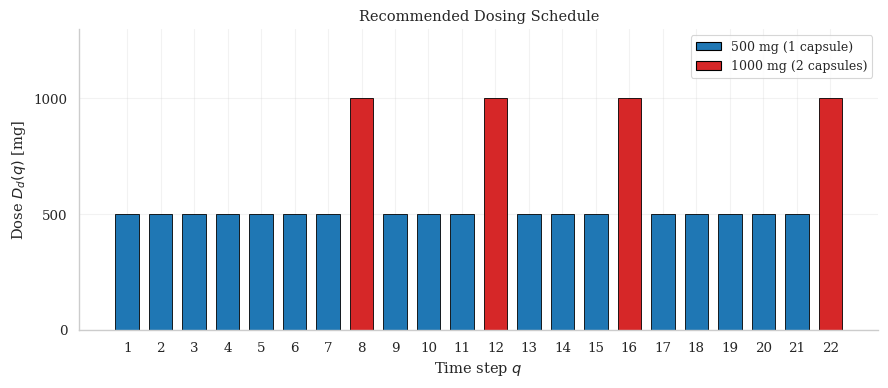

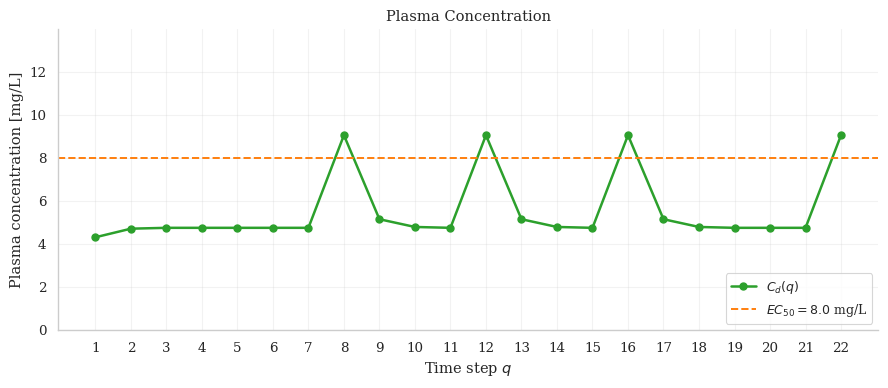

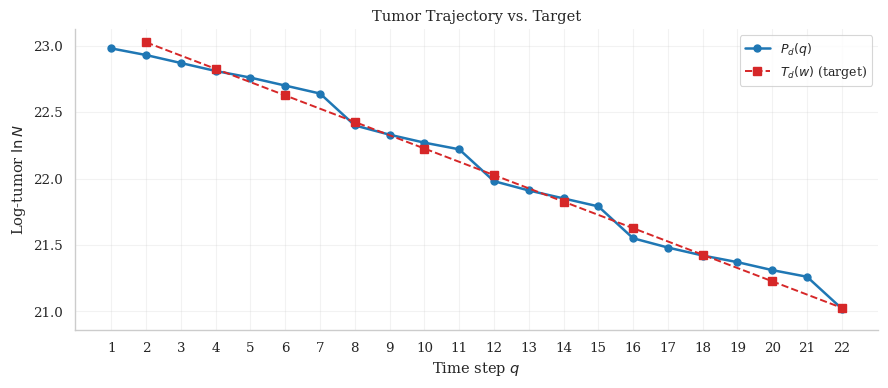

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

#  Evaluation 115 — hardcoded from logged callback output 
doses  = [500, 500, 500, 500, 500, 500, 500,
          1000,
          500, 500, 500,
          1000,
          500, 500, 500,
          1000,
          500, 500, 500, 500, 500,
          1000]

concs  = [4.31, 4.71, 4.75, 4.75, 4.75, 4.75, 4.75,
          9.06,
          5.15, 4.79, 4.75,
          9.06,
          5.15, 4.79, 4.75,
          9.06,
          5.15, 4.79, 4.75, 4.75, 4.75,
          9.06]

tumors = [22.98, 22.93, 22.87, 22.81, 22.76, 22.70, 22.64,
          22.40,
          22.33, 22.27, 22.22,
          21.98,
          21.91, 21.85, 21.79,
          21.55,
          21.48, 21.42, 21.37, 21.31, 21.26,
          21.02]

eval_env = HydroxyureaEnv(my_config)
obs, _ = eval_env.reset()

steps = list(range(1, eval_env.T + 1))

eval_steps = list(range(my_config.get("eval_interval", 2),
                         eval_env.T + 1,
                         my_config.get("eval_interval", 2)))
target = np.linspace(eval_env.ln_N0,
                     eval_env.ln_N0 - my_config.get("target_reduction", 2.0),
                     eval_env.W)

total_dose = sum(doses)
auc = (eval_env.h / 2) * concs[0] + eval_env.h * sum(concs[1:-1]) + (eval_env.h / 2) * concs[-1]
feasible = (auc <= eval_env.C_cum) and (total_dose >= eval_env.D_total_min)
obj = sum(abs(tumors[q-1] - target[i]) for i, q in enumerate(eval_steps))

print(f"Evaluation 115 | obj={obj:.4f} | P_d(final)={tumors[-1]:.4f} "
      f"| AUC={auc:.1f} mg/L·h | dose={total_dose} mg | feasible={feasible}")

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["font.family"] = "serif"

# Dosing schedule 
fig1, ax1 = plt.subplots(figsize=(9, 4))
colors = ["#d62728" if d == 1000 else "#1f77b4" for d in doses]
ax1.bar(steps, doses, color=colors, edgecolor="black", linewidth=0.6, width=0.7)
ax1.set_xticks(steps)
ax1.set_ylim(0, 1300)
ax1.set_yticks([0, 500, 1000])
ax1.set_xlabel("Time step $q$")
ax1.set_ylabel("Dose $D_d(q)$ [mg]")
ax1.set_title("Recommended Dosing Schedule")
ax1.legend(handles=[
    mpatches.Patch(facecolor="#1f77b4", edgecolor="black", label="500 mg (1 capsule)"),
    mpatches.Patch(facecolor="#d62728", edgecolor="black", label="1000 mg (2 capsules)"),
], loc="upper right", fontsize=9)
ax1.grid(alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Plasma concentration 
fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(steps, concs, marker="o", color="#2ca02c", linewidth=1.8, markersize=5, label="$C_d(q)$")
ax2.axhline(eval_env.C_th, color="#ff7f0e", linewidth=1.4, linestyle="--",
            label=f"$EC_{{50}} = {eval_env.C_th}$ mg/L")
ax2.set_xticks(steps)
ax2.set_ylim(0, 14)
ax2.set_yticks([0, 2, 4, 6, 8, 10, 12])
ax2.set_xlabel("Time step $q$")
ax2.set_ylabel("Plasma concentration [mg/L]")
ax2.set_title("Plasma Concentration")
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Tumor trajectory vs. target 
fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.plot(steps, tumors, marker="o", color="#1f77b4", linewidth=1.8,
         markersize=5, label="$P_d(q)$")
ax3.plot(eval_steps, target, marker="s", color="#d62728", linewidth=1.4,
         linestyle="--", markersize=6, label="$T_d(w)$ (target)")
ax3.set_xticks(steps)
_yrange = max(tumors + list(target)) - min(tumors + list(target))
ax3.set_ylim(min(tumors + list(target)) - _yrange * 0.08,
             max(tumors + list(target)) + _yrange * 0.05)
ax3.set_xlabel("Time step $q$")
ax3.set_ylabel("Log-tumor $\ln N$")
ax3.set_title("Tumor Trajectory vs. Target")
ax3.legend(loc="upper right", fontsize=9)
ax3.grid(alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# OAT Penalty Weight Sweep 
# Varies Gamma_u, pen_c8, pen_c9 one at a time (x0.5, x1 baseline, x2).

SWEEP = [
    ("Gamma_u x0.5",        "Gamma_u", 5e-6),
    ("Gamma_u x1 (baseline)", "Gamma_u", 1e-5),
    ("Gamma_u x2",           "Gamma_u", 2e-5),
    ("pen_c8  x0.5",         "pen_c8",  5.0),
    ("pen_c8  x1 (baseline)", "pen_c8",  10.0),
    ("pen_c8  x2",           "pen_c8",  20.0),
    ("pen_c9  x0.5",         "pen_c9",  2.5),
    ("pen_c9  x1 (baseline)", "pen_c9",  5.0),
    ("pen_c9  x2",           "pen_c9",  10.0),
]

n_envs_sweep  = 4
n_steps_sweep = 256

sweep_results = []

for label, param_name, param_value in SWEEP:
    print(f"Running: {label} ...", flush=True)

    # Build config for this run
    cfg = dict(my_config)
    cfg[param_name] = param_value

    env_s = make_vec_env(lambda cfg=cfg: HydroxyureaEnv(cfg), n_envs=n_envs_sweep)
    cb_s  = EpisodeCallback(
        eval_env_config=cfg,
        eval_freq=n_envs_sweep * n_steps_sweep,
        silent=True,
    )
    model_s = PPO(
        "MlpPolicy", env_s,
        learning_rate=3e-4,
        n_steps=n_steps_sweep,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        seed=42,
        verbose=0,
    )
    model_s.learn(total_timesteps=150_000, callback=cb_s)
    env_s.close()

    # Find best feasible evaluation
    feasible_pairs = [
        (obj, i)
        for i, (obj, feas) in enumerate(zip(cb_s.history_objs, cb_s.history_feasible))
        if feas
    ]

    if feasible_pairs:
        best_obj, best_idx = min(feasible_pairs)
        # Re-run that deterministic episode to read AUC and final P_d
        eval_env_s = HydroxyureaEnv(cfg)
        obs_s, _ = eval_env_s.reset()
        for _ in range(eval_env_s.T):
            act_s, _ = model_s.predict(obs_s, deterministic=True)
            obs_s, _, done_s, _, _ = eval_env_s.step(int(act_s))
            if done_s:
                break
        auc_s      = eval_env_s.auc
        pd_s       = eval_env_s.P_d
        dose_s     = eval_env_s.cumulative_dose
        feas_s     = auc_s <= eval_env_s.C_cum and dose_s >= eval_env_s.D_total_min
    else:
        best_obj = auc_s = pd_s = dose_s = float("nan")
        feas_s   = False

    sweep_results.append((label, best_obj, auc_s, pd_s, dose_s, feas_s))
    print(f"  obj={best_obj:.4f}  AUC={auc_s:.1f}  Pd={pd_s:.4f}  dose={dose_s:.0f}  feasible={feas_s}")


print(f"{'Configuration':<28} {'Obj':>7} {'AUC':>8} {'Final Pd':>10} {'Dose':>8} {'Feasible':>9}")
print("-" * 90)
for row in sweep_results:
    label, obj, auc, pd, dose, feas = row
    print(f"{label:<28} {obj:>7.4f} {auc:>8.1f} {pd:>10.4f} {dose:>8.0f} {str(feas):>9}")


Running: Gamma_u x0.5 ...
  obj=0.5694  AUC=1421.5  Pd=21.0021  dose=13000  feasible=True
Running: Gamma_u x1 (baseline) ...
  obj=0.6344  AUC=1418.9  Pd=21.0029  dose=13000  feasible=True
Running: Gamma_u x2 ...
  obj=0.7644  AUC=1421.5  Pd=21.0018  dose=13000  feasible=True
Running: pen_c8  x0.5 ...
  obj=0.6344  AUC=1421.7  Pd=21.0022  dose=13000  feasible=True
Running: pen_c8  x1 (baseline) ...
  obj=0.6344  AUC=1418.9  Pd=21.0029  dose=13000  feasible=True
Running: pen_c8  x2 ...
  obj=0.6474  AUC=1418.9  Pd=21.0029  dose=13000  feasible=True
Running: pen_c9  x0.5 ...
  obj=0.6344  AUC=1418.9  Pd=21.0031  dose=13000  feasible=True
Running: pen_c9  x1 (baseline) ...
  obj=0.6344  AUC=1418.9  Pd=21.0029  dose=13000  feasible=True
Running: pen_c9  x2 ...
  obj=0.6344  AUC=1421.5  Pd=21.0018  dose=13000  feasible=True
Configuration                    Obj      AUC   Final Pd     Dose  Feasible
------------------------------------------------------------------------------------------
Ga